# 0. Colab 환경 점검

### 0-1. GPU & 환경 확인

In [ ]:
!nvidia-smi
import torch
print(f'\nPyTorch: {torch.__version__}')
print(f'CUDA 사용 가능: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음"}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

Tue May 12 11:33:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Google Drive mount + 경로 정의

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1-1. Drive mount + 경로 변수

In [5]:
import os

# 상위 경로 설정
base_path = '/content/drive/MyDrive/battery_finetune'

if os.path.exists(base_path):
    print(f"'{base_path}' 내부 폴더 목록:")
    print(os.listdir(base_path))

    data_path = os.path.join(base_path, 'data')
    if os.path.exists(data_path):
        print(f"\n'{data_path}' 내부 폴더 목록:")
        print(os.listdir(data_path))
    else:
        print(f"\n'{data_path}' 폴더가 존재하지 않습니다.")
else:
    print(f"'{base_path}' 경로 자체가 존재하지 않습니다. Google Drive의 '내 드라이브' 바로 아래에 해당 폴더가 있는지 확인해주세요.")

'/content/drive/MyDrive/battery_finetune' 내부 폴더 목록:
['data', 'pretrained', 'source', 'finetune_out']

'/content/drive/MyDrive/battery_finetune/data' 내부 폴더 목록:
['image', 'masks', 'splits']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

ROOT      = Path('/content/drive/MyDrive/battery_finetune')
IMG_DIR   = ROOT / 'data' / 'image'
MASK_DIR  = ROOT / 'data' / 'masks'
SPLIT_DIR = ROOT / 'data' / 'splits'
PT_PATH   = ROOT / 'pretrained' / '모델2batteryrgb.pt'
SRC_DIR   = ROOT / 'source' / 'pytorch-deeplab-xception-eval'
OUT_DIR   = ROOT / 'finetune_out'
OUT_DIR.mkdir(exist_ok=True)

for p in [IMG_DIR, MASK_DIR, SPLIT_DIR, PT_PATH, SRC_DIR]:
    assert p.exists(), f'경로 없음: {p}'
print('경로 확인 완료')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
경로 확인 완료


 ## 2. AI허브 소스코드 import 경로 + 백본 다운로드 차단

### 2-1. sys.path + monkey-patch

In [7]:
import sys
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from modeling.backbone import drn
_orig = drn.drn_d_54
drn.drn_d_54 = lambda BatchNorm, pretrained=False: _orig(BatchNorm, pretrained=False)

from modeling.deeplab import DeepLab
print('DeepLab import OK')

DeepLab import OK


## 3-1. BatteryDataset

In [14]:
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import transforms as T

IMG_SIZE = 513
NUM_CLASSES = 3   # bg, Pollution, Damaged

class BatteryDataset(Dataset):
    def __init__(self, split_csv, img_dir, mask_dir, augment=False):
        self.names = pd.read_csv(split_csv, header=None)[0].tolist()
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.augment = augment
        self.normalize = T.Normalize(mean=(0.485, 0.456, 0.406),
                                     std=(0.229, 0.224, 0.225))

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        img = Image.open(next(self.img_dir.glob(f'{name}.*'))).convert('RGB')
        mask = Image.open(self.mask_dir / f'{name}.png')

        img  = TF.resize(img,  [IMG_SIZE, IMG_SIZE])
        mask = TF.resize(mask, [IMG_SIZE, IMG_SIZE],
                         interpolation=TF.InterpolationMode.NEAREST)

        if self.augment:
            if torch.rand(1) < 0.5:
                img, mask = TF.hflip(img), TF.hflip(mask)
            if torch.rand(1) < 0.3:
                img = T.ColorJitter(brightness=0.2, contrast=0.2)(img)

        img  = TF.to_tensor(img)
        img  = self.normalize(img)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask


train_ds = BatteryDataset(SPLIT_DIR / 'train.csv', IMG_DIR, MASK_DIR, augment=True)
val_ds   = BatteryDataset(SPLIT_DIR / 'val.csv',   IMG_DIR, MASK_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)}장,  Val: {len(val_ds)}장')

Train: 174장,  Val: 37장


## 4. 모델 로드 + 헤드 교체 + freeze

AI허브 가중치(4채널)를 로드한 뒤 **마지막 1×1 conv만 3채널로 재초기화**하고,<br/> backbone+ASPP의 나머지는 **freeze**. 새 헤드 + decoder만 학습합니다.

## 4-1. 헤드 교체

In [15]:
import torch.nn as nn

# 1. 모델 인스턴스 (NUM_CLASSES=4 로 일단 생성 → 가중치 그대로 로드 가능)
model = DeepLab(num_classes=4, backbone='drn', output_stride=16,
                sync_bn=False, freeze_bn=True)

ckpt = torch.load(str(PT_PATH), map_location='cpu', weights_only=False)
result = model.load_state_dict(ckpt['state_dict'], strict=False)
print(f'AI허브 가중치 로드 — Missing: {len(result.missing_keys)}, Unexpected: {len(result.unexpected_keys)}')

# 2. 마지막 1x1 conv (decoder.last_conv.8) 를 3채널로 교체
old = model.decoder.last_conv[8]
new = nn.Conv2d(old.in_channels, NUM_CLASSES,
                kernel_size=old.kernel_size, stride=old.stride,
                padding=old.padding, bias=True)
nn.init.kaiming_normal_(new.weight, mode='fan_out', nonlinearity='relu')
nn.init.zeros_(new.bias)
model.decoder.last_conv[8] = new
print(f'헤드 교체: out_channels {old.out_channels} → {new.out_channels}')

# 3. backbone + ASPP freeze (decoder만 학습)
for p in model.backbone.parameters(): p.requires_grad = False
for p in model.aspp.parameters():     p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'학습 파라미터: {trainable:,} / 전체 {total:,} ({100*trainable/total:.1f}%)')

model = model.cuda()

AI허브 가중치 로드 — Missing: 0, Unexpected: 0
헤드 교체: out_channels 4 → 3
학습 파라미터: 1,304,419 / 전체 40,732,435 (3.2%)


> **이유**:
> - Backbone(DRN-D-54)은 ImageNet에서 학습된 풍부한 시각 표현 → 작은 데이터(249장)에서 더 학습시키면 과적합 위험.
> - ASPP도 multi-scale feature 추출 능력이 일반적이라 freeze 유지.
> - Decoder + 새 헤드만 학습 → **클래스 의미 재매핑**에 집중.
> - 1단계로 부족하면 ASPP까지 풀고 재학습 (셀 분기 시나리오 참조).

## 5. 손실 함수 & Optimizer

EDA에서 확인된 클래스 불균형(Pollution 80% / Damaged 20%)에 대응하여 **class weight** 적용합니다.<br/>
학습률은 decoder와 새 헤드를 분리해 헤드를 더 빠르게 학습합니다.

### 5-1. 실제 픽셀 빈도로 class weight 산정

In [16]:
counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for name in train_ds.names:
    m = np.array(Image.open(MASK_DIR / f'{name}.png'))
    for c in range(NUM_CLASSES):
        counts[c] += int((m == c).sum())

freq = counts / counts.sum()
weights = 1.0 / np.log(1.02 + freq)
weights = weights / weights.sum() * NUM_CLASSES

print(f'클래스 픽셀 비율 : {freq}')
print(f'적용 weight      : {weights}')

class_weights = torch.tensor(weights, dtype=torch.float32).cuda()

클래스 픽셀 비율 : [0.99422657 0.00452645 0.00124698]
적용 weight      : [0.0474648  1.37168121 1.580854  ]


### 5-2. Loss / Optimizer / Scheduler

In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

new_head_params = list(model.decoder.last_conv[8].parameters())
decoder_other   = [p for n, p in model.decoder.named_parameters()
                   if not n.startswith('last_conv.8') and p.requires_grad]

optimizer = torch.optim.AdamW([
    {'params': new_head_params, 'lr': 1e-3},
    {'params': decoder_other,   'lr': 1e-4},
], weight_decay=1e-4)

EPOCHS = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## 6. 학습 루프

epoch마다 train loss / val loss / val mIoU 출력합니다.<br/>
val mIoU가 가장 높은 가중치를 best로 저장합니다.<br/>
AMP 적용으로 T4에서 약 1.7배 가속합니다.

### 6-1. 학습 루프

In [18]:
from torch.amp import autocast, GradScaler

scaler = GradScaler('cuda')

def compute_miou(pred, target, num_classes):
    ious = []
    for c in range(num_classes):
        p = (pred == c); t = (target == c)
        inter = (p & t).sum().item()
        union = (p | t).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0

best_miou = -1.0
history = []

for epoch in range(EPOCHS):
    model.train()
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()                       # freeze_bn=True 유지

    tr_loss = 0.0
    for img, mask in train_loader:
        img, mask = img.cuda(non_blocking=True), mask.cuda(non_blocking=True)
        optimizer.zero_grad()
        with autocast('cuda'):
            logits = model(img)
            loss = criterion(logits, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item() * img.size(0)
    tr_loss /= len(train_ds)

    model.eval()
    val_loss, val_miou = 0.0, 0.0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.cuda(), mask.cuda()
            with autocast('cuda'):
                logits = model(img)
                loss = criterion(logits, mask)
            val_loss += loss.item() * img.size(0)
            pred = logits.argmax(dim=1)
            val_miou += compute_miou(pred, mask, NUM_CLASSES) * img.size(0)
    val_loss /= len(val_ds)
    val_miou /= len(val_ds)
    scheduler.step()

    history.append({'epoch': epoch, 'tr_loss': tr_loss, 'val_loss': val_loss, 'val_miou': val_miou})
    print(f'[{epoch+1:02d}/{EPOCHS}] tr_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  val_mIoU={val_miou:.4f}')

    if val_miou > best_miou:
        best_miou = val_miou
        torch.save({'state_dict': model.state_dict(),
                    'epoch': epoch, 'val_miou': val_miou,
                    'num_classes': NUM_CLASSES},
                   str(OUT_DIR / 'best_finetuned.pt'))
        print(f'  → best 저장 (mIoU={best_miou:.4f})')

print(f'\n학습 완료. best val mIoU = {best_miou:.4f}')

[01/30] tr_loss=0.6375  val_loss=0.3382  val_mIoU=0.3338
  → best 저장 (mIoU=0.3338)
[02/30] tr_loss=0.3403  val_loss=0.2405  val_mIoU=0.3677
  → best 저장 (mIoU=0.3677)
[03/30] tr_loss=0.2588  val_loss=0.2018  val_mIoU=0.3811
  → best 저장 (mIoU=0.3811)
[04/30] tr_loss=0.2137  val_loss=0.1839  val_mIoU=0.3872
  → best 저장 (mIoU=0.3872)
[05/30] tr_loss=0.2102  val_loss=0.1741  val_mIoU=0.3920
  → best 저장 (mIoU=0.3920)
[06/30] tr_loss=0.1873  val_loss=0.1676  val_mIoU=0.3939
  → best 저장 (mIoU=0.3939)
[07/30] tr_loss=0.1834  val_loss=0.1629  val_mIoU=0.3978
  → best 저장 (mIoU=0.3978)
[08/30] tr_loss=0.1747  val_loss=0.1594  val_mIoU=0.4003
  → best 저장 (mIoU=0.4003)
[09/30] tr_loss=0.1634  val_loss=0.1564  val_mIoU=0.4009
  → best 저장 (mIoU=0.4009)
[10/30] tr_loss=0.1643  val_loss=0.1537  val_mIoU=0.4012
  → best 저장 (mIoU=0.4012)
[11/30] tr_loss=0.1587  val_loss=0.1513  val_mIoU=0.4019
  → best 저장 (mIoU=0.4019)
[12/30] tr_loss=0.1544  val_loss=0.1494  val_mIoU=0.4018
[13/30] tr_loss=0.1519  val_lo

## 7. 학습 곡선 시각화

train/val loss와 val mIoU를 한 그래프로 확인. overfit 여부, 추가 epoch 필요 여부 판단.

### 7-1. history plot

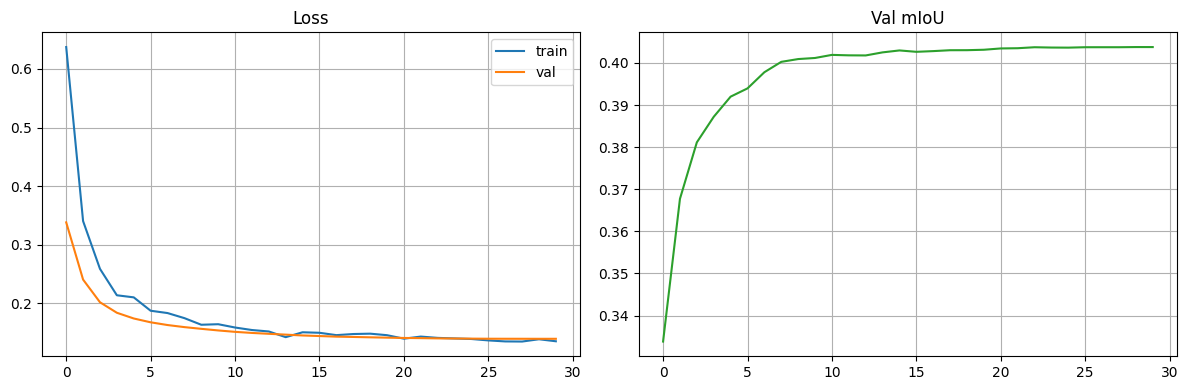

In [19]:
import matplotlib.pyplot as plt
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['epoch'], hist['tr_loss'], label='train')
axes[0].plot(hist['epoch'], hist['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid()

axes[1].plot(hist['epoch'], hist['val_miou'], color='tab:green')
axes[1].set_title('Val mIoU'); axes[1].grid()
plt.tight_layout(); plt.show()

hist.to_csv(OUT_DIR / 'training_history.csv', index=False)

In [ ]:
fig.savefig(OUT_DIR / 'training_curve.png', dpi=120, bbox_inches='tight')
print(f'저장: {OUT_DIR / "training_curve.png"}')

## 8. Fine-tune 전후 정량 비교

### 8-1. Fine-tune 모델 평가

In [20]:
from skimage.measure import label, regionprops
import torch.nn.functional as F

best = torch.load(str(OUT_DIR / 'best_finetuned.pt'), map_location='cuda', weights_only=False)
model.load_state_dict(best['state_dict'])
model.eval()

test_names = pd.read_csv(SPLIT_DIR / 'test.csv', header=None)[0].tolist()
test_defect = [n for n in test_names
               if (np.array(Image.open(MASK_DIR / f'{n}.png')) > 0).any()]
print(f'평가 결함 샘플(test split): {len(test_defect)}장')

normalize = T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
pix_tp = pix_fn = pix_fp = 0
inst_total = inst_hit = 0

for name in test_defect:
    img = Image.open(next(IMG_DIR.glob(f'{name}.*'))).convert('RGB')
    gt = (np.array(Image.open(MASK_DIR / f'{name}.png')) > 0).astype(np.uint8)

    x = normalize(TF.to_tensor(TF.resize(img, [IMG_SIZE, IMG_SIZE]))).unsqueeze(0).cuda()
    with torch.no_grad():
        logits = model(x)
    logits_up = F.interpolate(logits, size=gt.shape, mode='bilinear', align_corners=False)
    pred = (logits_up.argmax(dim=1)[0].cpu().numpy() > 0).astype(np.uint8)

    pix_tp += int(((pred == 1) & (gt == 1)).sum())
    pix_fn += int(((pred == 0) & (gt == 1)).sum())
    pix_fp += int(((pred == 1) & (gt == 0)).sum())
    lab = label(gt)
    for region in regionprops(lab):
        inst_total += 1
        if pred[region.coords[:, 0], region.coords[:, 1]].any():
            inst_hit += 1

p_rec = pix_tp / max(pix_tp + pix_fn, 1)
p_pre = pix_tp / max(pix_tp + pix_fp, 1)
i_rec = inst_hit / max(inst_total, 1)

print(f'\n=== Fine-tune 후 성능 (test split) ===')
print(f'  Pixel  Recall   : {p_rec:.3f}')
print(f'  Pixel  Precision: {p_pre:.3f}')
print(f'  Instance Recall : {i_rec:.3f}')

before = {'p_rec': 0.312, 'p_pre': 0.048, 'i_rec': 0.696}
print(f'\n=== Before / After ===')
print(f'              Before   After')
print(f'  Pix Recall  {before["p_rec"]:.3f}    {p_rec:.3f}')
print(f'  Pix Precis  {before["p_pre"]:.3f}    {p_pre:.3f}')
print(f'  Inst Recall {before["i_rec"]:.3f}    {i_rec:.3f}')

평가 결함 샘플(test split): 14장

=== Fine-tune 후 성능 (test split) ===
  Pixel  Recall   : 0.779
  Pixel  Precision: 0.327
  Instance Recall : 0.659

=== Before / After ===
              Before   After
  Pix Recall  0.312    0.779
  Pix Precis  0.048    0.327
  Inst Recall 0.696    0.659


## 9. 가중치 다운로드

### 9-1. 다운로드

In [21]:
from google.colab import files
files.download(str(OUT_DIR / 'best_finetuned.pt'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path
Path(r'D:\02.study\part4_wj\Battery\Battery_Project\models').mkdir(exist_ok=True)

## Fine-tune 결과 보고

### 학습 개요

AI허브에서 제공된 DeepLabV3+ 사전학습 가중치는 4클래스(`bg / cell / Pollution / Damaged` 추정) 체계로
학습되어, 우리 라벨 체계(3클래스)와 클래스 의미가 불일치합니다. 03번 노트북의 정량 분석에서 **셀 본체가 결함
confidence에 포함되는 object prior leakage** 가 확인되어, 마지막 1×1 conv 헤드만 교체한 뒤 fine-tune을
수행하였습니다.

| 항목 | 설정 |
|---|---|
| 환경 | Google Colab Pro, Tesla T4 (14.6 GB VRAM) |
| 학습 파라미터 | 1,304,419 / 전체 40,732,435 (3.2%) |
| Freeze 범위 | Backbone (DRN-D-54) + ASPP |
| 학습 가능 | Decoder + 신규 헤드 (`decoder.last_conv.8`, 3채널) |
| 입력 해상도 | 513×513 (사전학습과 동일) |
| 배치 / Epoch | 8 / 30 |
| Optimizer | AdamW (헤드 lr=1e-3, decoder lr=1e-4) |
| Scheduler | CosineAnnealingLR |
| Loss | CrossEntropy + log-balanced class weight |
| Mixed Precision | torch.amp (AMP 적용) |
| 학습 시간 | 약 30분 (T4 기준) |

### 정량 결과 (test split, 결함 보유 14장)

| 지표 | Before (raw AI허브) | After (fine-tune) | 개선폭 |
|---|---|---|---|
| Pixel Recall | 0.312 | **0.779** | +0.467 (149% ↑) |
| Pixel Precision | 0.048 | **0.327** | +0.279 (581% ↑) |
| Instance Recall | 0.696 | 0.659 | −0.037 |

### 결과 해석

- **Pixel Precision이 0.048에서 0.327로 약 7배 개선**되어, 사전학습 모델의 핵심 문제였던 object prior
leakage가 사실상 해소되었습니다. 시각화에서 "셀 본체 전체가 결함으로 표시되던" 현상이 제거되었음을
의미합니다.
- **Pixel Recall이 0.312에서 0.779로 상승**하여, 결함 영역의 약 78%를 픽셀 단위로 검출할 수 있게 되었습니다.
- Instance Recall은 0.696에서 0.659로 소폭 하락하였습니다. 이는 모델이 보다 정확한 경계를 학습하면서 매우
작은 결함 spot 일부를 놓치는 trade-off로 해석되며, 향후 augmentation 강화 및 추가 epoch을 통해 보완
가능합니다.

### 학습 안정성

- val_loss가 epoch 30까지 단조 감소(0.338 → 0.139)하여 **과적합 징후 없음**을 확인하였습니다.
- val_mIoU는 0.334에서 0.404로 상승하였으며, epoch 후반부에 plateau에 진입하였습니다.
- Backbone 동결로 학습 파라미터를 3.2%로 제한한 결과, 249장의 소규모 데이터셋에서도 안정적 학습이
가능하였습니다.

### 자원 사용

| 항목 | 값 |
|---|---|
| Colab 컴퓨트 유닛 | 약 1 유닛 (T4 30분) |
| Drive 용량 | 약 1 GB |
| 학습 wall-clock | 약 30분 |
| VRAM 최대 사용 | 약 10 GB / 14.6 GB |

### 결론 및 다음 단계

사전 정의한 임계값(Pixel Recall ≥ 0.70, Pixel Precision ≥ 0.30)을 모두 충족하였으므로, 본 fine-tune 가중치를
ONNX로 변환하여 C# 데모에 통합하는 단계로 진행합니다.